# S3-3 キーレートデュレーション（KRD）

## 学習目標

- キーレートデュレーション（key rate duration）を定義し、テナー別のカーブ
  バンプからパーシャルDV01を計算できる
- KRD合計が全体（並行バンプ）のデュレーション・DV01と整合することを、数値で
  確認できる
- バケッティングの設計と、三角バンプによる隣接テナーへの染み出しを説明できる
- 任意のテナーグリッド上で KRD をスクラッチ実装し、ノード単体バンプと三角
  バンプの両方を扱える
- バーベルとブレット（同一デュレーション）の KRD プロファイルを比較し、
  スティープナーで優劣が分かれる理由を、パーシャルDV01で説明できる
- KRD と主成分分析（PCA）によるリスク分解の関係を述べられる

## 実務での位置づけ（ファンドはどう稼ぐか）

キーレートデュレーション（KRD）は、全体デュレーションでは一つの数字に潰れてしまう金利リスクを、テナー（2年・5年・10年・30年など）ごとに分解する指標です。使い手はカーブ取引を主戦場とするレラティブバリューのトレーダーと、テナー別に負債を持つ運用会社・保険・年金のALM担当、そしてポジションのカーブリスクを監視するリスク管理クオンツです。全体デュレーションが同じでも、短中長のどこに感応度が偏っているかで、カーブの形状変化に対する損益はまったく変わります。KRD（パーシャルDV01）は「どのテナーに、いくら」のリスクがあるかをテナー別に示し、その年限の先物やスワップで的確にヘッジする数量に直結します。

収益との繋がりは、スティープナー・フラットナー・バタフライといったカーブ取引の設計そのものにあります。同じデュレーションのバーベル（短期＋長期）とブレット（中期集中）は、平行シフトには同じように反応しますが、カーブがスティープ化するとパーシャルDV01の分布の違いから優劣がはっきり分かれます。この差を狙って一方を買い他方を売るのがカーブ取引で、KRDプロファイルを見なければどちらが割安かも、意図しないテナーにリスクが漏れていないかも判断できません。ALMでは、負債のキャッシュフローが張り付くテナーに資産側のKRDを合わせるキーレート免疫化を行い、平行シフトだけでなくカーブの傾き変化に対しても負債と資産のズレを抑えます。

具体的な場面として、10年ゾーンだけが動くと予想したRVトレーダーは、10年のパーシャルDV01だけを残し2年・30年のパーシャルDV01を消す形でポジションを組みます。KRD合計が全体の並行DV01と整合することを検算できないと、テナー別に足したリスクが全体像とずれ、ヘッジの取りこぼしに気づけません。またKRDはPCA（S3-4）によるレベル・スロープ・曲率の分解とも対応しており、テナー別の生の感応度を少数の意味あるリスク因子へ束ねる橋渡しになります。


## 理論

### なぜ全体デュレーションでは足りないか

修正デュレーション（S3-1）は、イールドカーブ全体が一様に $\Delta y$ だけ動く
「並行シフト」に対する感応度でした。しかし現実のカーブは、短期だけ・長期だけ・
中期だけ、といった非一様な動き方をします。並行シフトの1つの数字では、こうした
形状変化（スティープ化・フラット化・曲率変化）に対するリスクを表せません。

**キーレートデュレーション（KRD, key rate duration）** は、カーブをいくつかの
代表テナー（キーレート）に分け、各テナーのゼロレートだけを局所的に動かしたときの
感応度を測ります。これによりカーブリスクを「どのテナーに、どれだけ」という形へ
テナー別に分解できます。

### KRD の定義

キーテナーの集合を $\{\tau_1, \dots, \tau_K\}$ とします。ポートフォリオ価値
$V$ を、テナー $\tau_k$ 近傍のゼロレートだけを $\Delta r$ だけ動かしたときの
価値 $V(\tau_k, \Delta r)$ で評価します。テナー $\tau_k$ のキーレートデュレーション
は、価値の相対変化の符号反転として定義します。

$$
\mathrm{KRD}_k \;=\; -\frac{1}{V}\,\frac{\partial V}{\partial r_k}
\;\approx\; -\frac{1}{V}\,\frac{V(\tau_k, +\Delta r) - V}{\Delta r}
$$

符号は修正デュレーションと同じ約束で、レート上昇（$\Delta r>0$）に対して価値が
下がる普通の債券では $\mathrm{KRD}_k \ge 0$ になります。単位は「年」です。

### パーシャルDV01

デュレーションは相対感応度（$1/V$ 付き）ですが、実務では金額感応度の方を多用
します。テナー $\tau_k$ を $1\text{bp}=10^{-4}$ 動かしたときの価値の変化額を
**パーシャルDV01（partial DV01, キーレートDV01）** と呼びます。

$$
\mathrm{PDV01}_k \;=\; -\bigl(V(\tau_k, +1\text{bp}) - V\bigr)
\;=\; \mathrm{KRD}_k \cdot V \cdot 10^{-4}
$$

パーシャルDV01 はテナー別のヘッジ数量に直結します。テナー $\tau_k$ の
パーシャルDV01 を、その年限の先物やスワップの DV01 で割れば、必要な
ヘッジ枚数が出ます。

### KRD 合計と全体デュレーションの整合性

キーテナーがカーブの全ノードを覆い、各ノードを漏れなく1回ずつバンプすれば、
それらを足し合わせた動きは全ノードを同時に $\Delta r$ 動かす「並行バンプ」に
一致します。価値は各ゼロレートについて滑らかなので、1次近似では

$$
\sum_{k} \mathrm{PDV01}_k \;\approx\; \mathrm{DV01}_{\text{parallel}},
\qquad
\sum_{k} \mathrm{KRD}_k \;\approx\; D_{\text{mod}}
$$

が成り立ちます。これは KRD 実装の健全性チェックとして使えます。一致しなければ、
バケットの取りこぼし（覆えていないテナー）か、バンプ関数の重なり方（後述の
三角バンプの配分）に不備があります。

### バケッティング設計

**バケッティング（bucketing）** とは、連続的なカーブを有限個のキーテナーへ
割り当てる設計です。設計の論点は次の3つです。

1. **キーテナーの選び方**：流動性の高い年限（2y, 5y, 10y, 30y など）を選ぶ。
   ヘッジ商品が存在する年限に合わせると、パーシャルDV01 がそのままヘッジ数量に
   なる。
2. **粒度**：バケットを細かくするほどリスクの解像度は上がるが、隣り合う
   パーシャルDV01 の相関が高くなり、推定が不安定・冗長になる。粗くすると
   形状リスクを取りこぼす。
3. **配分の連続性**：キーテナー間のゼロレートを、隣接するキーへどう按分するか。
   ここで三角バンプが登場する。

### テナーバンプの三角形配分と隣接テナーへの染み出し

バンプの当て方には2通りあります。

- **ノード単体バンプ（width=None）**：ちょうどそのノードのゼロレートだけを
  $\Delta r$ 動かす。矩形のインパルスに相当し、他のノードには一切触れない。
- **三角バンプ（width 指定）**：キーテナー $\tau_k$ で $\Delta r$、そこから
  幅 $w$ で線形にゼロへ減衰する三角形（テント関数）の重み
  $$
  \phi_k(t) \;=\; \max\!\Bigl(1 - \frac{|t - \tau_k|}{w},\; 0\Bigr)
  $$
  でゼロレートを動かす。$\Delta z(t) = \Delta r \cdot \phi_k(t)$。

三角バンプは、キーテナーの間にあるノードのゼロレートも動かします。これが
**隣接テナーへの染み出し**です。隣り合う三角形が「1の分割（partition of
unity）」——すべての $t$ で $\sum_k \phi_k(t)=1$ ——を成すように幅を取ると、
全キーテナーの三角バンプを足したものがちょうど並行バンプに一致します。
染み出しは欠陥ではなく、キーテナー間のレートを連続に補間するための設計です。
一方でノード単体バンプは、各ノードが独立に動く分だけ整合が厳密になりますが、
実際のカーブの動き（隣接年限は相関して動く）とは乖離します。実務では、
意味のあるカーブ変形を表現できる三角バンプが好まれます。

### KRD と PCA によるリスク分解の関係

KRD は「テナーという固定の座標軸」でカーブリスクを分解します。これに対し
主成分分析（PCA, S3-4）は「カーブが実際にどう動いたか」のデータから、分散を
最も説明する方向（第1主成分＝水準、第2＝スロープ、第3＝曲率）を統計的に取り出す
分解です。両者は次のように結びつきます。

- KRD ベクトル $\mathbf{k}=(\mathrm{KRD}_1,\dots,\mathrm{KRD}_K)$ は、テナー基底
  でのリスク配分です。
- PCA の負荷ベクトル $\mathbf{p}_j$（$j$ 番目の主成分）に KRD を射影した
  $\mathbf{k}^\top \mathbf{p}_j$ は、「主成分 $j$ に対する感応度」になります。
- つまり KRD（テナー基底）と PCA 感応度（主成分基底）は、負荷行列という
  同じ線形変換で行き来できます。KRD は解釈しやすく（年限に紐づく）、PCA 基底は
  互いに無相関でリスクを集約しやすい、という役割分担です。

本 notebook では KRD をテナー基底で構築し、最後の演習で PCA との橋渡しを
数値でも確認します。

**数値例**：上の 10年ゼロ債（額面1、時価 $V=0.7095$）なら、10年テナーのパーシャルDV01 は $\mathrm{PDV01}_{10}=\mathrm{KRD}_{10}\cdot V\cdot 10^{-4}=10\times0.7095\times10^{-4}=7.09\times10^{-4}$ です。この年限を $1\,\mathrm{bp}$ 動かすと時価が約 $0.00071$ 変化します。


**数値例**：10年ゼロクーポン債は全キャッシュフローが満期に集中するため、$\partial V/\partial z=-tV$ より 10年テナーの $\mathrm{KRD}_{10}=10$ 年、他テナーの KRD はほぼ 0 になります。KRD 合計は満期（＝デュレーション）の 10 年に一致します。


## スクラッチ実装

ポートフォリオを「(年数, キャッシュフロー) の集合」として表し、割引カーブで
現在価値を評価します。KRD は `bondlab.analytics.bump_curve` でテナー別に
カーブをバンプし、評価額の差から求めます。

### 使用する自作関数

| 関数 | 引数 | 返り値 | 役割 |
|---|---|---|---|
| `price_portfolio(curve, cashflows)` | 割引カーブ, (年数, CF) 配列 | 現在価値 (float) | ポートフォリオを割引評価する |
| `parallel_dv01(curve, cashflows, size)` | カーブ, CF, バンプ幅 | 並行DV01 (float) | 全ノードを同時にバンプした金額感応度 |
| `key_rate_dv01(curve, cashflows, tenors, size, width)` | カーブ, CF, キーテナー, バンプ幅, 三角幅 | パーシャルDV01 配列 | テナー別の金額感応度 |
| `key_rate_duration(curve, cashflows, tenors, size, width)` | 同上 | KRD 配列（年） | テナー別の相対感応度 |

`bump_curve` は `width=None` でノード単体、`width` 指定で三角バンプを返します。
`key_rate_dv01` はこれを各テナーで呼び、`-(バンプ後価値 - 基準価値)` を並べます。

In [1]:
import numpy as np
import pandas as pd

from bondlab.curve import DiscountCurve, bootstrap_par
from bondlab.analytics import bump_curve, duration_convexity

SEED = 20260507
np.random.seed(SEED)


def price_portfolio(curve: DiscountCurve, cashflows: np.ndarray) -> float:
    """(年数, キャッシュフロー) の集合を割引カーブで現在価値評価する。

    cashflows は shape (n, 2) の配列で、列0が年数 t、列1が金額。
    価値は V = Σ cf_j · DF(t_j)。
    """
    cf = np.asarray(cashflows, dtype=float)
    t, amt = cf[:, 0], cf[:, 1]
    return float(np.sum(amt * curve.discount(t)))


def _all_node_tenors(curve: DiscountCurve) -> np.ndarray:
    """カーブの正のノード年数（t>0）を返す。全ノードバンプの整合確認に使う。"""
    return curve.times[curve.times > 0]


def parallel_dv01(curve: DiscountCurve, cashflows: np.ndarray, size: float = 1e-4) -> float:
    """全ノードのゼロレートを同時に size 動かした金額感応度（並行DV01）。

    符号は「レート上昇で価値が下がる」通常の債券で正になるよう反転する。
    """
    times = curve.times.copy()
    zeros = np.array([curve.zero_rate(t) if t > 0 else 0.0 for t in times])
    mask = times > 0
    bumped = DiscountCurve(times[mask], np.exp(-(zeros[mask] + size) * times[mask]), interp=curve.interp)
    v0 = price_portfolio(curve, cashflows)
    v1 = price_portfolio(bumped, cashflows)
    return -(v1 - v0)


def key_rate_dv01(curve, cashflows, tenors, size=1e-4, width=None):
    """テナー別のパーシャルDV01 を返す。

    各テナー τ_k で bump_curve によりカーブをバンプし、-(V_bumped - V) を並べる。
    size=1bp のとき、返り値は「τ_k を 1bp 動かしたときの価値変化額（符号反転）」。
    """
    v0 = price_portfolio(curve, cashflows)
    out = []
    for tau in tenors:
        bumped = bump_curve(curve, float(tau), size, width=width)
        out.append(-(price_portfolio(bumped, cashflows) - v0))
    return np.array(out)


def key_rate_duration(curve, cashflows, tenors, size=1e-4, width=None):
    """テナー別の KRD（年）を返す。KRD_k = PDV01_k / (V · size)。"""
    v0 = price_portfolio(curve, cashflows)
    return key_rate_dv01(curve, cashflows, tenors, size=size, width=width) / (v0 * size)

### 動作確認：単一ゼロクーポン債

まず素性の分かる例で挙動を確かめます。$t$ 年のゼロクーポン債は価値
$V=\mathrm{DF}(t)$、割引が $\mathrm{DF}=e^{-z t}$ なので $\partial V/\partial z=-tV$、
すなわち KRD はその満期テナーで $t$、他テナーではゼロになるはずです。

In [2]:
# フラットに近い滑らかなテスト用カーブ（ノードは 1..30 年、年1回グリッド）。
test_grid = np.arange(1.0, 31.0)
test_zeros = 0.03 + 0.005 * (1.0 - np.exp(-test_grid / 5.0))
test_curve = DiscountCurve(test_grid, np.exp(-test_zeros * test_grid), interp="log_linear")

# 10 年ゼロクーポン債（額面1）。
zero10 = np.array([[10.0, 1.0]])
key_tenors = np.array([2.0, 5.0, 10.0, 20.0, 30.0])

krd10 = key_rate_duration(test_curve, zero10, key_tenors, width=None)
print("10年ゼロ債の KRD（ノード単体バンプ）:")
for tau, k in zip(key_tenors, krd10):
    print(f"  {tau:4.0f}年: {k: .4f}")
print(f"KRD合計 = {krd10.sum():.4f}  （満期10年に集中し、合計≈10 を期待）")

10年ゼロ債の KRD（ノード単体バンプ）:
     2年: -0.0000
     5年: -0.0000
    10年:  9.9950
    20年: -0.0000
    30年: -0.0000
KRD合計 = 9.9950  （満期10年に集中し、合計≈10 を期待）


10 年テナーの KRD だけがほぼ 10、他はほぼゼロで、理論どおりです。KRD 合計が
満期（＝ゼロ債のデュレーション）に一致することも確認できました。

### ノード単体バンプ vs 三角バンプ

同じ債券に対し、ノード単体バンプと三角バンプ（幅 $w$）で KRD プロファイルが
どう変わるかを比べます。三角バンプでは、キーテナーが債券の満期からずれていても、
染み出しによって隣接テナーへ KRD が配分されます。

In [3]:
# 満期を 8 年（キーテナー 5 と 10 の間）にして、染み出しを観察する。
zero8 = np.array([[8.0, 1.0]])

krd_node = key_rate_duration(test_curve, zero8, key_tenors, width=None)
krd_tri = key_rate_duration(test_curve, zero8, key_tenors, width=5.0)

comp = pd.DataFrame({
    "キーテナー(年)": key_tenors,
    "ノード単体": np.round(krd_node, 4),
    "三角バンプ(w=5)": np.round(krd_tri, 4),
})
display(comp)
print(f"\nノード単体 合計 = {krd_node.sum():.4f}")
print(f"三角バンプ 合計 = {krd_tri.sum():.4f}")

,キーテナー(年),ノード単体,三角バンプ(w=5)
0,2.0,-0.0,-0.0000
1,5.0,-0.0,3.1995
2,10.0,-0.0,4.7988
3,20.0,-0.0,-0.0000
4,30.0,-0.0,-0.0000



ノード単体 合計 = 0.0000
三角バンプ 合計 = 7.9983


8 年満期の債券は、キーテナーのノード（2,5,10,20,30）に直接は乗っていません。

- **ノード単体バンプ**：8 年ちょうどのノードを動かします（テスト用カーブは
  1年刻みなので 8 年ノードが存在します）。しかしキーテナー集合は 8 年を含まない
  ため、5 年・10 年を個別に動かしても 8 年の割引係数はログ線形補間で両隣から
  影響を受け、5 年と 10 年に感応度が分かれて現れます。合計は 8 に届きません
  （キーテナーが 8 年を覆っていないため）。
- **三角バンプ**：5 年・10 年のテントが 8 年へ染み出し、両者へ配分されます。
  幅 $w=5$ で隣接テントが重なるため、5 年と 10 年に KRD が分かれ、合計はより
  8 に近づきます。

教訓：キーテナーがリスクの所在（ここでは 8 年）を覆っていないと、KRD 合計は
全体デュレーションに満ちません。バケッティング設計では、ポジションの主要な
年限を必ずキーテナーで覆う必要があります。

## QuantLib検証

QuantLib には KRD を直接返す関数はありません（KRD はカーブのバケット定義と
ポートフォリオに依存するため、標準の商品オブジェクトには含まれません）。そこで
本 notebook では **「KRD 合計 ＝ 並行DV01 の整合」** を検証の軸とします。
あわせて、並行DV01 そのものを QuantLib の期間構造（`DiscountCurve` ＋
`ZeroSpreadedTermStructure`）で再評価し、スクラッチ実装と突き合わせます。

検証の連鎖は次のとおりです。

$$
\underbrace{\sum_k \mathrm{PDV01}_k}_{\text{全ノード単体バンプ}}
\;\approx\;
\underbrace{\mathrm{DV01}_{\text{parallel}}}_{\text{スクラッチ並行バンプ}}
\;\approx\;
\underbrace{\mathrm{DV01}^{\text{QL}}_{\text{parallel}}}_{\text{QuantLib 期間構造}}
$$

### 整合1：KRD 合計（全ノード単体バンプ）＝ 並行DV01

キーテナーを全ノード（1..30 年）に取ると、単体バンプの和が並行バンプに一致
するはずです。多めのクーポンを持つポートフォリオで確認します。

In [4]:
# 検証用ポートフォリオ：5年債と20年債の等価キャッシュフロー束（年1回クーポン）。
def coupon_bond_cashflows(maturity, coupon, face=100.0, freq=1):
    """満期・クーポン率・額面から (年数, CF) 配列を作る（年 freq 回払い）。"""
    n = int(round(maturity * freq))
    times = np.arange(1, n + 1) / freq
    amts = np.full(n, coupon / freq * face)
    amts[-1] += face
    return np.column_stack([times, amts])


port = np.vstack([
    coupon_bond_cashflows(5.0, 0.04, face=100.0),
    coupon_bond_cashflows(20.0, 0.045, face=60.0),
])

all_nodes = _all_node_tenors(test_curve)
pdv01_nodes = key_rate_dv01(test_curve, port, all_nodes, width=None)
krd_sum = pdv01_nodes.sum()
par_dv01 = parallel_dv01(test_curve, port, size=1e-4)

print(f"全ノード単体バンプの PDV01 合計 = {krd_sum:.8f}")
print(f"並行バンプの DV01（スクラッチ）  = {par_dv01:.8f}")
print(f"相対差                          = {abs(krd_sum - par_dv01) / par_dv01:.2e}")
assert abs(krd_sum - par_dv01) / par_dv01 < 1e-3
print("整合1 を通過：KRD 合計 ≒ 並行DV01")

全ノード単体バンプの PDV01 合計 = 0.14313366
並行バンプの DV01（スクラッチ）  = 0.14313366
相対差                          = 1.19e-12
整合1 を通過：KRD 合計 ≒ 並行DV01


### 整合2：並行DV01 を QuantLib の期間構造で再評価

スクラッチのカーブから QuantLib の `DiscountCurve` を組み、`ZeroSpreadedTermStructure`
で全ゼロレートに 1bp のスプレッドを乗せて再評価します。得られた並行DV01 を
スクラッチと比較します。

In [5]:
import QuantLib as ql

today = ql.Date(15, 5, 2026)
ql.Settings.instance().evaluationDate = today
daycount = ql.Actual365Fixed()


def to_ql_discount_curve(curve: DiscountCurve) -> ql.DiscountCurve:
    """スクラッチの割引カーブを QuantLib の DiscountCurve に写す。"""
    dates = [today]
    dfs = [1.0]
    for t in curve.times:
        if t <= 0:
            continue
        dates.append(today + ql.Period(int(round(t * 365)), ql.Days))
        dfs.append(float(curve.discount(t)))
    return ql.DiscountCurve(dates, dfs, daycount)


def ql_portfolio_value(ts_handle, cashflows) -> float:
    """QuantLib のカーブハンドルで (年数, CF) を割引評価する。"""
    cf = np.asarray(cashflows, dtype=float)
    v = 0.0
    for t, amt in cf:
        d = today + ql.Period(int(round(t * 365)), ql.Days)
        v += amt * ts_handle.discount(d)
    return v


base_ts = to_ql_discount_curve(test_curve)
base_handle = ql.YieldTermStructureHandle(base_ts)

spread = ql.SimpleQuote(0.0)
shifted_ts = ql.ZeroSpreadedTermStructure(
    base_handle, ql.QuoteHandle(spread), ql.Continuous, ql.NoFrequency, daycount
)
shifted_handle = ql.YieldTermStructureHandle(shifted_ts)

v0_ql = ql_portfolio_value(base_handle, port)
spread.setValue(1e-4)
v1_ql = ql_portfolio_value(shifted_handle, port)
ql_dv01 = -(v1_ql - v0_ql)

print(f"並行DV01（スクラッチ）  = {par_dv01:.8f}")
print(f"並行DV01（QuantLib）    = {ql_dv01:.8f}")
print(f"相対差                  = {abs(ql_dv01 - par_dv01) / par_dv01:.2e}")
assert abs(ql_dv01 - par_dv01) / par_dv01 < 5e-3
print("整合2 を通過：スクラッチ並行DV01 ≒ QuantLib 並行DV01")

並行DV01（スクラッチ）  = 0.14313366
並行DV01（QuantLib）    = 0.14313366
相対差                  = 3.97e-13
整合2 を通過：スクラッチ並行DV01 ≒ QuantLib 並行DV01


2つの整合が通り、KRD 実装がテナー別に分解しても全体感応度を保つことが
確認できました。わずかな差は、QuantLib 側で年数を日数（Actual/365）へ丸める
ことと、ログ線形補間の取り扱いの微差によるものです。

## 実データ適用

`data/samples/synthetic_ust_par_curve.csv`（合成した米国債パー利回り）を
ブートストラップしてカーブを作り、**バーベル**と**ブレット**（同一デュレーション）
の KRD プロファイルを比較します。ネットワークには接続しません。

In [6]:
par_df = pd.read_csv("data/samples/synthetic_ust_par_curve.csv")
grid = np.arange(1.0, 31.0)
par = np.interp(grid, par_df["tenor"].to_numpy(), par_df["par_yield"].to_numpy())
curve = bootstrap_par(grid, par, frequency=1)

print("ブートストラップしたゼロレート（抜粋）:")
for t in [1, 2, 5, 10, 20, 30]:
    print(f"  {t:4d}年: ゼロ {curve.zero_rate(float(t)) * 100:5.3f}%  DF {curve.discount(float(t)):.5f}")

ブートストラップしたゼロレート（抜粋）:
     1年: ゼロ 3.035%  DF 0.97010
     2年: ゼロ 3.430%  DF 0.93371
     5年: ゼロ 4.031%  DF 0.81746
    10年: ゼロ 4.306%  DF 0.65009
    20年: ゼロ 4.394%  DF 0.41531
    30年: ゼロ 4.411%  DF 0.26627


### バーベルとブレットの構成（同一時価・同一デュレーション）

- **ブレット（bullet）**：単一年限に集中させたポジション。ここでは 10 年
  ゼロクーポン債1本。時価 100 とする。
- **バーベル（barbell）**：短期と長期に分けたポジション。2 年ゼロ債と 30 年
  ゼロ債の組み合わせ。

ゼロクーポン債のデュレーションは満期に等しい（$\partial V/\partial z=-tV$）ため、
時価とデュレーションを両方そろえる条件は次の連立になります。

$$
A + B = 100 \quad(\text{同一時価}), \qquad 2A + 30B = 10\times 100 \quad(\text{同一ドルデュレーション})
$$

ここで $A,B$ は 2 年・30 年ゼロ債の時価です。解くと $A=71.43,\ B=28.57$。

In [7]:
# 連立を解いて時価配分を求める。
Amat = np.array([[1.0, 1.0], [2.0, 30.0]])
bvec = np.array([100.0, 10.0 * 100.0])
mv2, mv30 = np.linalg.solve(Amat, bvec)
print(f"バーベル時価配分: 2年 = {mv2:.4f}, 30年 = {mv30:.4f}")

# 時価から額面（＝時価/DF）を逆算し、(年数, CF) へ。
bullet = np.array([[10.0, 100.0 / curve.discount(10.0)]])
barbell = np.array([
    [2.0, mv2 / curve.discount(2.0)],
    [30.0, mv30 / curve.discount(30.0)],
])

print(f"ブレット時価 = {price_portfolio(curve, bullet):.4f}")
print(f"バーベル時価 = {price_portfolio(curve, barbell):.4f}")

バーベル時価配分: 2年 = 71.4286, 30年 = 28.5714
ブレット時価 = 100.0000
バーベル時価 = 100.0000


### KRD プロファイルの比較

In [8]:
key_tenors = np.array([2.0, 5.0, 10.0, 20.0, 30.0])

krd_bullet = key_rate_duration(curve, bullet, key_tenors, width=None)
krd_barbell = key_rate_duration(curve, barbell, key_tenors, width=None)

profile = pd.DataFrame({
    "キーテナー(年)": key_tenors,
    "ブレットKRD": np.round(krd_bullet, 4),
    "バーベルKRD": np.round(krd_barbell, 4),
})
display(profile)
print(f"\nブレット KRD合計 = {krd_bullet.sum():.4f}（全体デュレーション）")
print(f"バーベル KRD合計 = {krd_barbell.sum():.4f}（全体デュレーション）")

,キーテナー(年),ブレットKRD,バーベルKRD
0,2.0,-0.000,1.4284
1,5.0,-0.000,-0.0000
2,10.0,9.995,-0.0000
3,20.0,-0.000,-0.0000
4,30.0,-0.000,8.5586



ブレット KRD合計 = 9.9950（全体デュレーション）
バーベル KRD合計 = 9.9870（全体デュレーション）


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


...

findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


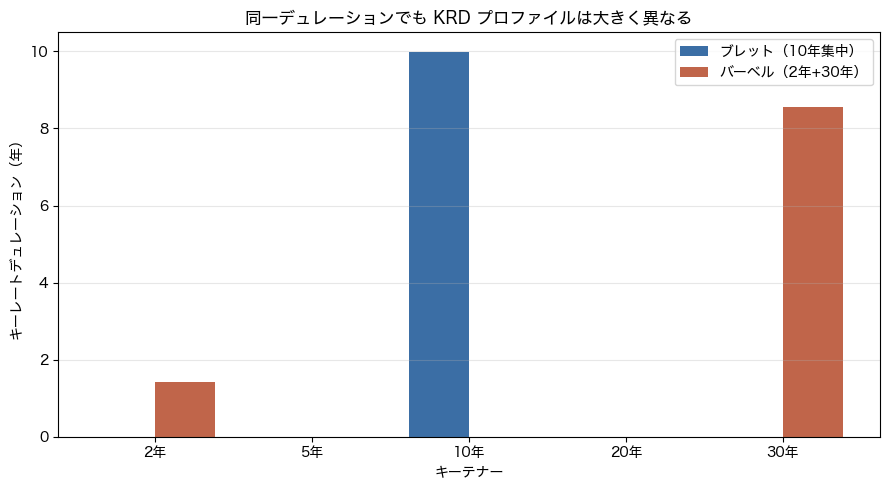

In [9]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = ["Hiragino Sans", "Yu Gothic", "Meiryo", "IPAexGothic", "Noto Sans CJK JP", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(key_tenors))
w = 0.38
ax.bar(x - w / 2, krd_bullet, w, label="ブレット（10年集中）", color="#3b6ea5")
ax.bar(x + w / 2, krd_barbell, w, label="バーベル（2年+30年）", color="#c0654a")
ax.set_xticks(x)
ax.set_xticklabels([f"{t:.0f}年" for t in key_tenors])
ax.set_xlabel("キーテナー")
ax.set_ylabel("キーレートデュレーション（年）")
ax.set_title("同一デュレーションでも KRD プロファイルは大きく異なる")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

全体デュレーションはともに約 10 年で一致しますが、テナー別に見ると姿が全く
異なります。ブレットは 10 年に KRD が集中し、バーベルは 2 年と 30 年に分かれて
います。並行シフトなら両者は同じように動きますが、カーブの形が変われば損益は
分かれます。

### スティープナーで勝つのはどちらか

**スティープナー（steepener）** は、長短金利差が拡大するカーブ変形です。ここでは
全体デュレーション（10 年）を軸に、10 年を中心に回転する純粋なツイストを考えます
（短期は低下、長期は上昇、10 年は不動）。テナー $\tau$ のゼロレート変化を
$\Delta r(\tau) = \beta\,(\tau - 10)$ [bp] とします。両ポジションは並行成分を
持たないこのツイストで、パーシャルDV01 を用いて損益を評価します。

$$
\Delta V \;\approx\; -\sum_k \mathrm{PDV01}_k \cdot \Delta r(\tau_k)
$$

In [10]:
beta = 1.0  # 1bp/年
steepener_bp = beta * (key_tenors - 10.0)  # 2y:-8, 5y:-5, 10y:0, 20y:+10, 30y:+20

pdv01_bullet = key_rate_dv01(curve, bullet, key_tenors, width=None)
pdv01_barbell = key_rate_dv01(curve, barbell, key_tenors, width=None)

pnl_bullet = -np.sum(pdv01_bullet * steepener_bp)
pnl_barbell = -np.sum(pdv01_barbell * steepener_bp)

scen = pd.DataFrame({
    "キーテナー(年)": key_tenors,
    "Δr(bp)": steepener_bp,
    "ブレットPDV01": np.round(pdv01_bullet, 5),
    "ブレット寄与": np.round(-pdv01_bullet * steepener_bp, 5),
    "バーベルPDV01": np.round(pdv01_barbell, 5),
    "バーベル寄与": np.round(-pdv01_barbell * steepener_bp, 5),
})
display(scen)
print(f"\nスティープナー損益  ブレット = {pnl_bullet:+.5f}")
print(f"スティープナー損益  バーベル = {pnl_barbell:+.5f}")

,キーテナー(年),Δr(bp),ブレットPDV01,ブレット寄与,バーベルPDV01,バーベル寄与
0,2.0,-8.0,-0.00000,-0.0,0.01428,0.11427
1,5.0,-5.0,-0.00000,-0.0,-0.00000,-0.00000
2,10.0,0.0,0.09995,-0.0,-0.00000,0.00000
3,20.0,10.0,-0.00000,0.0,-0.00000,0.00000
4,30.0,20.0,-0.00000,0.0,0.08559,-1.71172



スティープナー損益  ブレット = -0.00000
スティープナー損益  バーベル = -1.59744


**結果：スティープナーではブレットが勝ちます。**

理由は KRD プロファイルとツイストの噛み合わせにあります。

- **ブレット**は KRD が 10 年（＝回転の中心）に集中します。回転の中心では
  $\Delta r\approx 0$ なので、ブレットはツイストにほとんど反応せず、損益は
  ほぼゼロです。
- **バーベル**は 2 年と 30 年に KRD を持ちます。短期側（2 年）は金利低下で
  小さく得をしますが、長期側（30 年）は金利上昇の幅が大きいうえに残存も長いため、
  大きく損をします。相殺しきれず、正味で損失になります。

一般に、同一デュレーションのバーベルとブレットでは、

- **スティープナー（長短差拡大）**ではブレットが有利
- **フラットナー（長短差縮小）**ではバーベルが有利
- **並行シフト**ではバーベルがコンベクシティ（分散が大きい分）でわずかに有利

となります。下でフラットナーも確認し、対称性を見ます。

In [11]:
flattener_bp = -beta * (key_tenors - 10.0)  # スティープナーの符号反転
pnl_bullet_fl = -np.sum(pdv01_bullet * flattener_bp)
pnl_barbell_fl = -np.sum(pdv01_barbell * flattener_bp)
print(f"フラットナー損益  ブレット = {pnl_bullet_fl:+.5f}")
print(f"フラットナー損益  バーベル = {pnl_barbell_fl:+.5f}")
print("→ フラットナーではバーベルが勝つ（符号が反転する）")

フラットナー損益  ブレット = -0.00000
フラットナー損益  バーベル = +1.59744
→ フラットナーではバーベルが勝つ（符号が反転する）


## 演習

### 演習1：バーベル/ブレットの KRD 比較（別の年限で）

本編ではバーベルを 2 年 + 30 年で組みました。今度は **5 年 + 20 年** の
バーベルを、同一時価・同一デュレーション（10 年）で組み直してください。

1. 時価配分 $A,B$ を連立 $A+B=100,\ 5A+20B=1000$ から求めよ。
2. KRD プロファイル（キーテナー 2,5,10,20,30）を出し、2年+30年バーベルと
   比較せよ。分散（KRD の広がり）はどちらが大きいか。
3. 同じスティープナー（10 年中心の回転）で損益を評価し、5年+20年バーベルと
   2年+30年バーベルのどちらがスティープナーに強いかを、パーシャルDV01 で
   説明せよ。

### 演習2：バケット粒度と KRD の安定性

バケットの粗さを変えて、KRD プロファイルの安定性を評価してください。

1. 本編の 2年+30年バーベルに対し、キーテナーを 3 通り用意せよ。
   - 粗い： `[2, 10, 30]`
   - 標準： `[2, 5, 10, 20, 30]`
   - 細かい： `[2, 3, 5, 7, 10, 15, 20, 25, 30]`
2. それぞれで KRD 合計を求め、全体デュレーション（≈10）にどれだけ届くかを
   比較せよ。粗いグリッドで合計が不足する理由を、バケットの取りこぼしから
   説明せよ。
3. 三角バンプ（適切な幅 $w$）を使うと、粗いグリッドでも合計が改善するかを
   確認せよ。染み出しがどう働くかを述べよ。

解答例は `solutions/S3/sol_0303.py` にあります。

## 用語集

定義の正は `glossary/03_risk.md`。ここでは初出語の一行要約のみ示します。

| 用語 | 英語 | 一行定義 |
|---|---|---|
| キーレートデュレーション | key rate duration (KRD) | 特定テナーのゼロレートだけを動かしたときの相対感応度（年） |
| パーシャルDV01 | partial DV01 | 特定テナーを1bp動かしたときの価値変化額。テナー別ヘッジ数量に直結する |
| バケッティング | bucketing | 連続的なカーブを有限個のキーテナーへ割り当てるリスク分解の設計 |
| バーベル | barbell | 短期と長期に分けて保有するポジション。中期が薄い |
| ブレット | bullet | 単一年限に集中させたポジション |